In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import joblib
import warnings
# Suppressing the  warnings
warnings.filterwarnings("ignore")


### Reading Datasets

In [158]:
ingridients = pd.read_csv('Pizza_ingredients.csv')
sale = pd.read_csv('Pizza_Sale.csv')

In [159]:
ingridients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pizza_name_id       518 non-null    object 
 1   pizza_name          518 non-null    object 
 2   pizza_ingredients   518 non-null    object 
 3   Items_Qty_In_Grams  514 non-null    float64
dtypes: float64(1), object(3)
memory usage: 16.3+ KB


In [160]:
ingridients.describe().T

,count,mean,std,min,25%,50%,75%,max
Items_Qty_In_Grams,514.0,30.564202,30.351623,5.0,10.0,20.0,40.0,200.0


In [161]:
ingridients.head()

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0


In [162]:
sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48604 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48613 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48597 non-null  object 
 10  pizza_ingredients  48607 non-null  object 
 11  pizza_name         48613 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [163]:
sale.describe().T

,count,mean,std,min,25%,50%,75%,max
pizza_id,48620.0,24310.500000,14035.529381,1.00,12155.75,24310.5,36465.25,48620.00
order_id,48620.0,10701.479761,6180.119770,1.00,5337.00,10682.5,16100.00,21350.00
quantity,48620.0,1.019622,0.143077,1.00,1.00,1.0,1.00,4.00
unit_price,48620.0,16.494132,3.621789,9.75,12.75,16.5,20.25,35.95
total_price,48613.0,16.821494,4.437520,9.75,12.75,16.5,20.50,83.00


In [164]:
sale.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


### Handling Missing Values

In [165]:
ingridients.isnull().sum()

pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    4
dtype: int64

In [166]:
ingridients['pizza_ingredients'].unique()

array(['Barbecued Chicken', 'Red Peppers', 'Green Peppers', 'Tomatoes',
       'Red Onions', 'Barbecue Sauce', 'Bacon', 'Pepperoni',
       'Italian Sausage', 'Chorizo Sausage', 'Brie Carre Cheese',
       'Prosciutto', 'Caramelized Onions', 'Pears', 'Thyme', 'Garlic',
       '?duja Salami', 'Pancetta', 'Friggitello Peppers', 'Chicken',
       'Artichokes', 'Spinach', 'Jalapeno Peppers', 'Fontina Cheese',
       'Gouda Cheese', 'Mushrooms', 'Asiago Cheese', 'Alfredo Sauce',
       'Pesto Sauce', 'Mozzarella Cheese', 'Provolone Cheese',
       'Smoked Gouda Cheese', 'Romano Cheese', 'Blue Cheese',
       'Ricotta Cheese', 'Gorgonzola Piccante Cheese',
       'Parmigiano Reggiano Cheese', 'Green Olives', 'Feta Cheese',
       'Sliced Ham', 'Pineapple', 'Capocollo', 'Goat Cheese', 'Oregano',
       'Calabrese Salami', 'Eggplant', 'Zucchini', 'Kalamata Olives',
       'Sun-dried Tomatoes', 'Plum Tomatoes', 'Cilantro', 'Corn',
       'Chipotle Sauce', 'Anchovies', 'Genoa Salami',
       'Pr

In [167]:
ingridients['pizza_ingredients'].replace('?duja Salami','Nduja Salami',inplace=True)

In [168]:
ingridients[ingridients['Items_Qty_In_Grams'].isnull()]

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
24,brie_carre_s,The Brie Carre Pizza,Caramelized Onions,NaN
149,hawaiian_l,The Hawaiian Pizza,Sliced Ham,NaN
152,hawaiian_m,The Hawaiian Pizza,Sliced Ham,NaN
155,hawaiian_s,The Hawaiian Pizza,Sliced Ham,NaN


In [169]:
ingridients[ingridients['pizza_name'] == 'The Brie Carre Pizza']

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
22,brie_carre_s,The Brie Carre Pizza,Brie Carre Cheese,30.0
23,brie_carre_s,The Brie Carre Pizza,Prosciutto,30.0
24,brie_carre_s,The Brie Carre Pizza,Caramelized Onions,NaN
25,brie_carre_s,The Brie Carre Pizza,Pears,10.0
26,brie_carre_s,The Brie Carre Pizza,Thyme,5.0
27,brie_carre_s,The Brie Carre Pizza,Garlic,5.0


In [170]:
ingridients[ingridients['pizza_name'] == 'The Hawaiian Pizza']

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
149,hawaiian_l,The Hawaiian Pizza,Sliced Ham,NaN
150,hawaiian_l,The Hawaiian Pizza,Pineapple,45.0
151,hawaiian_l,The Hawaiian Pizza,Mozzarella Cheese,30.0
152,hawaiian_m,The Hawaiian Pizza,Sliced Ham,NaN
153,hawaiian_m,The Hawaiian Pizza,Pineapple,30.0
154,hawaiian_m,The Hawaiian Pizza,Mozzarella Cheese,20.0
155,hawaiian_s,The Hawaiian Pizza,Sliced Ham,NaN
156,hawaiian_s,The Hawaiian Pizza,Pineapple,15.0
157,hawaiian_s,The Hawaiian Pizza,Mozzarella Cheese,10.0


In [171]:
ingridients.groupby('pizza_name_id')['Items_Qty_In_Grams'].mean()

pizza_name_id
bbq_ckn_l        30.000000
bbq_ckn_m        20.833333
bbq_ckn_s        13.333333
big_meat_s       65.000000
brie_carre_s     16.000000
                   ...    
the_greek_xl     61.666667
the_greek_xxl    80.000000
veggie_veg_l     34.375000
veggie_veg_m     23.125000
veggie_veg_s     13.125000
Name: Items_Qty_In_Grams, Length: 91, dtype: float64

In [172]:
qty_mean = ingridients.groupby('pizza_name_id')['Items_Qty_In_Grams'].mean()

In [173]:
ingridients['Items_Qty_In_Grams'] = ingridients['Items_Qty_In_Grams'].fillna(ingridients['pizza_name_id'].map(qty_mean))

In [174]:
ingridients.isnull().sum()

pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    0
dtype: int64

In [175]:
sale.isnull().sum()

pizza_id              0
order_id              0
pizza_name_id        16
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           7
pizza_size            0
pizza_category       23
pizza_ingredients    13
pizza_name            7
dtype: int64

In [176]:
sale['total_price'].fillna(sale['unit_price'] * sale['quantity'], inplace=True)

In [177]:
sale[sale['pizza_name_id'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
36,37,15,NaN,1,1/1/2015,13:33:00,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
37,38,15,NaN,1,1/1/2015,13:33:00,20.75,20.75,L,Supreme,"Soppressata Salami, Fontina Cheese, Mozzarella...",The Soppressata Pizza
38,39,15,NaN,1,1/1/2015,13:33:00,12.00,12.00,S,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza
39,40,16,NaN,1,1/1/2015,13:34:07,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
40,41,16,NaN,1,1/1/2015,13:34:07,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
41,42,16,NaN,1,1/1/2015,13:34:07,20.75,20.75,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza
309,310,131,NaN,1,2/1/2015,21:33:10,12.00,12.00,S,Veggie,"Spinach, Mushrooms, Tomatoes, Green Olives, Fe...",The Green Garden Pizza
310,311,131,NaN,1,2/1/2015,21:33:10,12.50,12.50,S,Supreme,"Spinach, Red Onions, Pepperoni, Tomatoes, Arti...",The Spinach Supreme Pizza
311,312,132,NaN,1,2/1/2015,21:42:45,9.75,9.75,S,Classic,"Mozzarella Cheese, Pepperoni",The Pepperoni Pizza
312,313,133,NaN,1,2/1/2015,22:00:17,20.75,20.75,L,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [178]:
pizza_name_id_mapping = (
    sale[['pizza_name', 'pizza_name_id']]  
    .dropna()
    .drop_duplicates()
    .set_index('pizza_name')['pizza_name_id']
    .to_dict()
)

sale['pizza_name_id'] = sale['pizza_name_id'].fillna(
    sale['pizza_name'].map(pizza_name_id_mapping)
)

sale['pizza_name_id'] = sale['pizza_name_id'].str.replace(r'(_xxl|_xl|_l|_m|_s)$', '', regex=True)

sale['pizza_name_id'] = sale.apply(
    lambda row: f"{row['pizza_name_id']}_{row['pizza_size'].lower()}" if pd.notna(row['pizza_name_id']) else row['pizza_name_id'],
    axis=1
)


In [179]:
sale[sale['pizza_name_id'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name


In [180]:
sale[sale['pizza_category'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
426,427,181,mexicana_l,1,3/1/2015,18:49:32,20.25,20.25,L,NaN,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
427,428,182,brie_carre_s,1,3/1/2015,18:50:10,23.65,23.65,S,NaN,"Brie Carre Cheese, Prosciutto, Caramelized Oni...",The Brie Carre Pizza
428,429,182,peppr_salami_l,1,3/1/2015,18:50:10,20.75,20.75,L,NaN,"Genoa Salami, Capocollo, Pepperoni, Tomatoes, ...",The Pepper Salami Pizza
429,430,183,napolitana_m,1,3/1/2015,18:54:55,16.00,16.00,M,NaN,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
430,431,183,spin_pesto_l,1,3/1/2015,18:54:55,20.75,20.75,L,NaN,"Spinach, Artichokes, Tomatoes, Sun-dried Tomat...",The Spinach Pesto Pizza
431,432,183,spin_pesto_s,1,3/1/2015,18:54:55,12.50,12.50,S,NaN,"Spinach, Artichokes, Tomatoes, Sun-dried Tomat...",The Spinach Pesto Pizza
432,433,184,hawaiian_l,1,3/1/2015,18:59:05,16.50,16.50,L,NaN,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
433,434,185,sicilian_m,1,3/1/2015,19:08:33,16.25,16.25,M,NaN,"Coarse Sicilian Salami, Tomatoes, Green Olives...",The Sicilian Pizza
434,435,185,spin_pesto_s,1,3/1/2015,19:08:33,12.50,12.50,S,NaN,"Spinach, Artichokes, Tomatoes, Sun-dried Tomat...",The Spinach Pesto Pizza
435,436,186,mexicana_l,1,3/1/2015,19:36:00,20.25,20.25,L,NaN,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [181]:
pizza_category_mapping = (
    sale[['pizza_name', 'pizza_category']]
    .dropna()
    .drop_duplicates()
    .set_index('pizza_name')['pizza_category']
    .to_dict()  
)

sale['pizza_category'] = sale['pizza_category'].fillna(
    sale['pizza_name'].map(pizza_category_mapping)
)


In [182]:
sale[sale['pizza_category'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name


In [183]:
sale[sale['pizza_ingredients'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
580,581,254,five_cheese_l,1,4/1/2015,22:22:13,18.50,18.50,L,Veggie,NaN,The Five Cheese Pizza
581,582,255,five_cheese_l,1,5/1/2015,11:23:35,18.50,18.50,L,Veggie,NaN,The Five Cheese Pizza
582,583,255,green_garden_m,1,5/1/2015,11:23:35,16.00,16.00,M,Veggie,NaN,The Green Garden Pizza
583,584,255,hawaiian_l,1,5/1/2015,11:23:35,16.50,16.50,L,Classic,NaN,The Hawaiian Pizza
584,585,255,spinach_fet_m,1,5/1/2015,11:23:35,16.00,16.00,M,Veggie,NaN,The Spinach and Feta Pizza
585,586,256,pep_msh_pep_l,1,5/1/2015,11:56:06,17.50,17.50,L,Classic,NaN,"The Pepperoni, Mushroom, and Peppers Pizza"
586,587,257,cali_ckn_l,1,5/1/2015,11:59:04,20.75,20.75,L,Chicken,NaN,The California Chicken Pizza
630,631,277,four_cheese_m,1,5/1/2015,15:41:50,14.75,14.75,M,Veggie,NaN,The Four Cheese Pizza
631,632,278,ital_veggie_m,1,5/1/2015,15:49:21,16.75,16.75,M,Veggie,NaN,The Italian Vegetables Pizza
632,633,278,southw_ckn_l,1,5/1/2015,15:49:21,20.75,20.75,L,Chicken,NaN,The Southwest Chicken Pizza


In [184]:
pizza_ingredients_mapping = (
    sale[['pizza_name_id', 'pizza_ingredients']]
    .dropna()  
    .drop_duplicates()  
    .set_index('pizza_name_id')['pizza_ingredients']
    .to_dict() 
)

sale['pizza_ingredients'] = sale['pizza_ingredients'].fillna(
    sale['pizza_name_id'].map(pizza_ingredients_mapping)
)

In [185]:
sale[sale['pizza_ingredients'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name


In [186]:
sale[sale['pizza_name'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
688,689,303,pepperoni_s,1,5/1/2015,20:02:51,9.75,9.75,S,Classic,"Mozzarella Cheese, Pepperoni",NaN
689,690,304,hawaiian_s,1,5/1/2015,20:07:58,10.50,10.50,S,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",NaN
690,691,304,mexicana_l,1,5/1/2015,20:07:58,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",NaN
691,692,305,pepperoni_l,1,5/1/2015,20:35:40,15.25,15.25,L,Classic,"Mozzarella Cheese, Pepperoni",NaN
692,693,305,sicilian_s,1,5/1/2015,20:35:40,12.25,12.25,S,Supreme,"Coarse Sicilian Salami, Tomatoes, Green Olives...",NaN
693,694,305,spicy_ital_m,1,5/1/2015,20:35:40,16.50,16.50,M,Supreme,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",NaN
694,695,306,big_meat_s,1,5/1/2015,20:37:40,12.00,12.00,S,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau...",NaN


In [187]:
pizza_name_mapping = (
    sale[['pizza_name_id', 'pizza_name']]
    .dropna()
    .drop_duplicates()
    .set_index('pizza_name_id')['pizza_name']
    .to_dict()
)

sale['pizza_name'] = sale['pizza_name'].fillna(
    sale['pizza_name_id'].map(pizza_name_mapping)
)


In [188]:
sale[sale['pizza_name'].isnull()]

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name


In [189]:
ingridients.isnull().sum()

pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    0
dtype: int64

In [190]:
sale.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [191]:
sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [192]:
sale['order_date'].head(2)

0    1/1/2015
1    1/1/2015
Name: order_date, dtype: object

In [193]:
def extract_date(date):
    date_formats = ['%d-%m-%Y', '%d/%m/%Y', '%m/%d/%Y']
    for format in date_formats:
        try:
            return pd.to_datetime(date, format=format)
        except ValueError:
            continue
    return pd.NaT

sale['order_date'] = sale['order_date'].apply(extract_date)

In [194]:
sale['order_date'].tail(10)

48610   2015-12-31
48611   2015-12-31
48612   2015-12-31
48613   2015-12-31
48614   2015-12-31
48615   2015-12-31
48616   2015-12-31
48617   2015-12-31
48618   2015-12-31
48619   2015-12-31
Name: order_date, dtype: datetime64[ns]

In [195]:
sale['day_of_week'] = sale['order_date'].dt.day_of_week

In [196]:
sale['month'] = sale['order_date'].dt.month

In [197]:
sale['week'] = sale['order_date'].dt.isocalendar().week

In [198]:
import holidays

holidays = holidays.CountryHoliday('US')

sale['is_holiday'] = sale['order_date'].apply(lambda x: x in holidays)


In [199]:
sale['is_holiday'].value_counts()

is_holiday
False    47125
True      1495
Name: count, dtype: int64

In [200]:
sale[['order_date', 'day_of_week', 'month', 'week', 'is_holiday']].head()

,order_date,day_of_week,month,week,is_holiday
0,2015-01-01,3,1,1,True
1,2015-01-01,3,1,1,True
2,2015-01-01,3,1,1,True
3,2015-01-01,3,1,1,True
4,2015-01-01,3,1,1,True


In [201]:
sale['order_time'] = pd.to_datetime(sale['order_time'], format='%H:%M:%S', errors='coerce')

sale['order_hour'] = sale['order_time'].dt.hour

def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

sale['time_of_day'] = sale['order_hour'].apply(time_of_day)

In [202]:
sale.columns, ingridients.columns

(Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
        'order_time', 'unit_price', 'total_price', 'pizza_size',
        'pizza_category', 'pizza_ingredients', 'pizza_name', 'day_of_week',
        'month', 'week', 'is_holiday', 'order_hour', 'time_of_day'],
       dtype='object'),
 Index(['pizza_name_id', 'pizza_name', 'pizza_ingredients',
        'Items_Qty_In_Grams'],
       dtype='object'))

### EDA

Sale

In [203]:
fig = px.line(sale, x='order_date', y='total_price', title='Total Price of Pizzas Over Time')
fig.show()

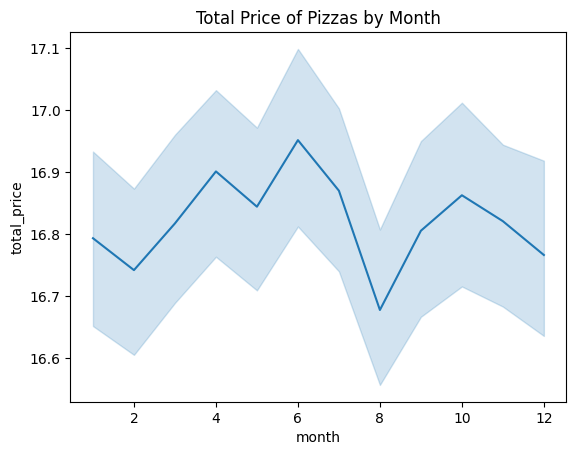

In [204]:
sns.lineplot(x='month', y='total_price', data=sale)
plt.title('Total Price of Pizzas by Month')
plt.show()

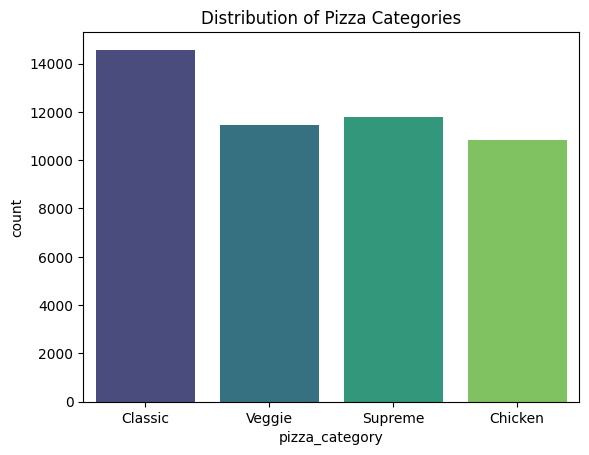

In [205]:
sns.countplot(x='pizza_category', data=sale, palette='viridis')
plt.title('Distribution of Pizza Categories')
plt.show()

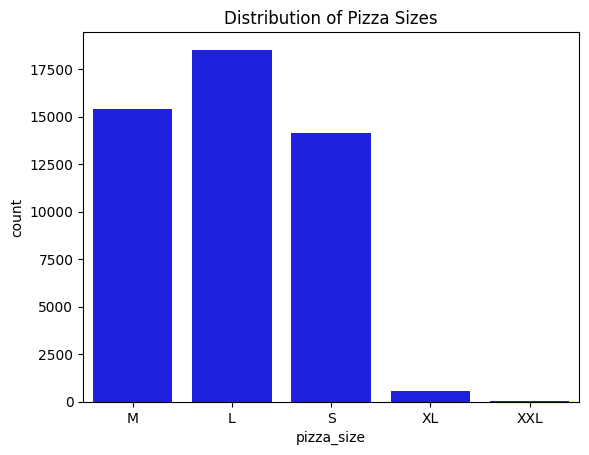

In [206]:
sns.countplot(x='pizza_size', data=sale, color='b')
plt.title('Distribution of Pizza Sizes')
plt.show()

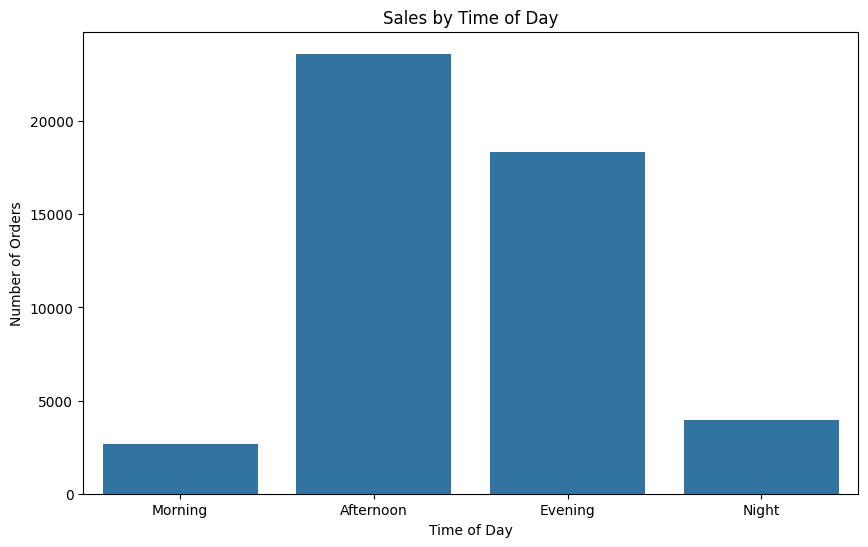

In [207]:
plt.figure(figsize=(10, 6))
sns.countplot(x='time_of_day', data=sale, order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title('Sales by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Orders')
plt.show()

Text(0.5, 0, 'Hour of the Day')

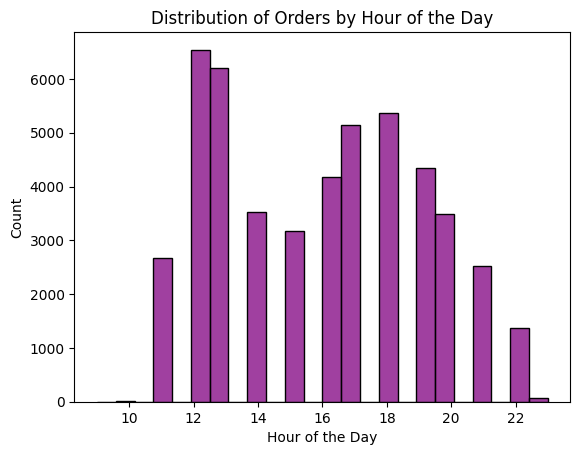

In [208]:
sns.histplot(sale['order_hour'], bins=24, color='purple')
plt.title('Distribution of Orders by Hour of the Day')
plt.xlabel('Hour of the Day')

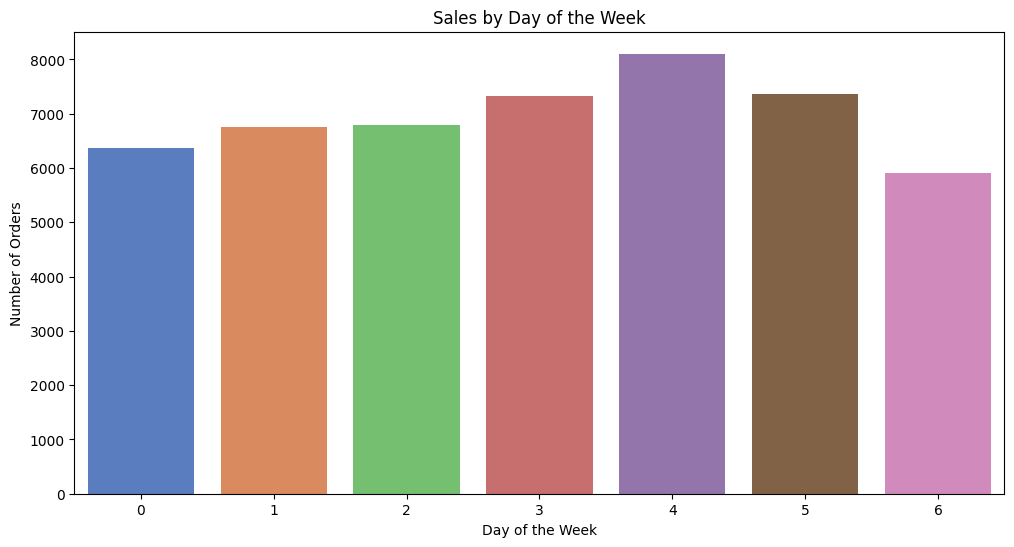

In [209]:
plt.figure(figsize=(12, 6))
sns.countplot(x='day_of_week', data=sale, palette='muted')
plt.title('Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.show()

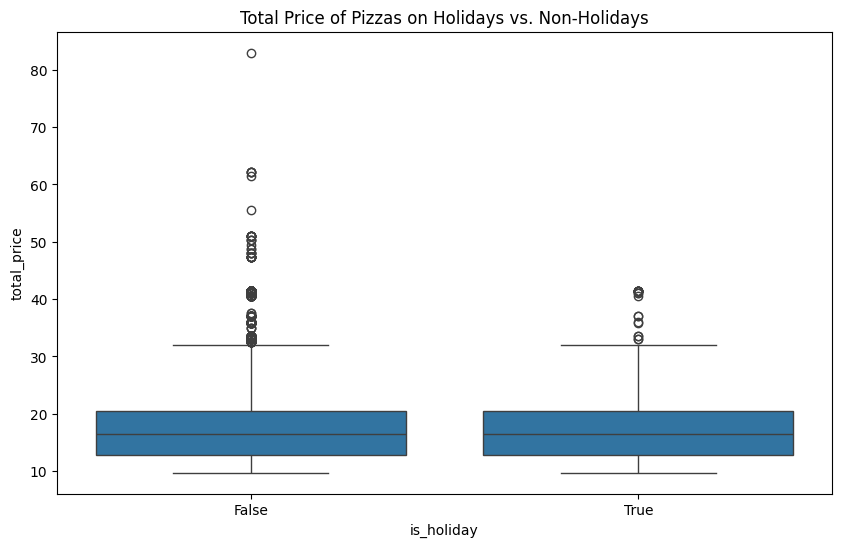

In [210]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_holiday', y='total_price', data=sale)
plt.title('Total Price of Pizzas on Holidays vs. Non-Holidays')
plt.show()

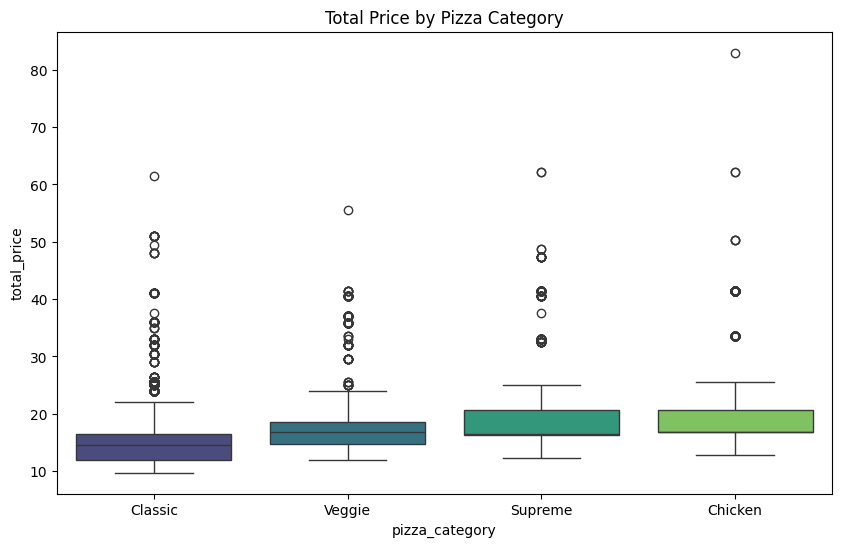

In [211]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='pizza_category', y='total_price', data=sale, palette='viridis')
plt.title('Total Price by Pizza Category')
plt.show()


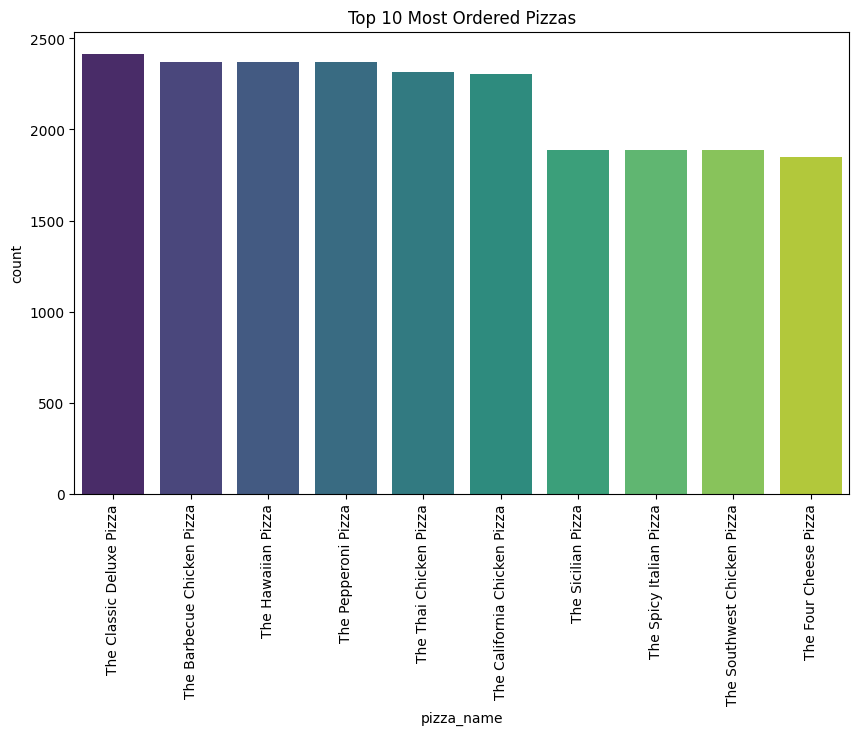

In [212]:
# Most ordered pizza
plt.figure(figsize=(10, 6))
sns.countplot(x='pizza_name', data=sale, order=sale['pizza_name'].value_counts().nlargest(10).index, palette='viridis')
plt.title('Top 10 Most Ordered Pizzas')
plt.xticks(rotation=90)
plt.show()

Ingredients

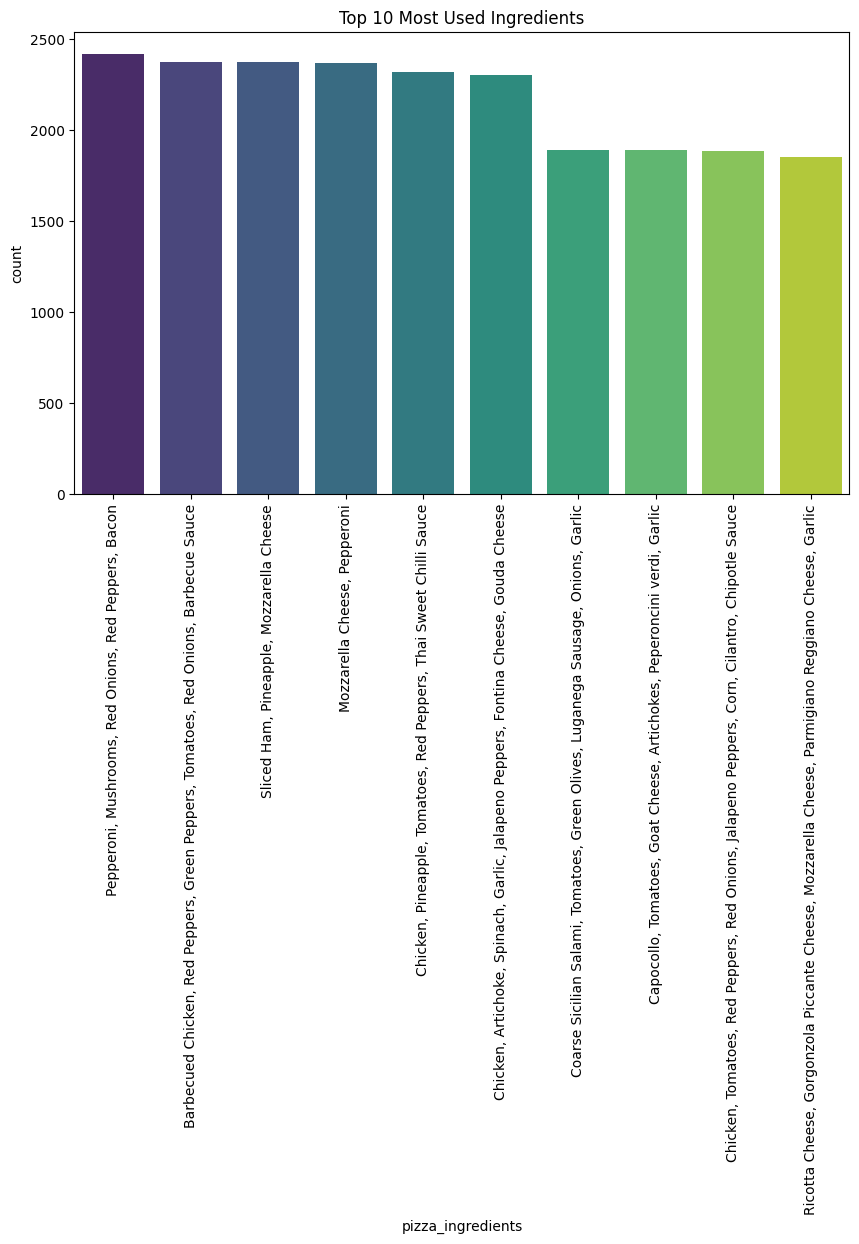

In [213]:
# Most used ingredients
plt.figure(figsize=(10, 6))
sns.countplot(x='pizza_ingredients', data=sale, order=sale['pizza_ingredients'].value_counts().nlargest(10).index, palette='viridis')
plt.title('Top 10 Most Used Ingredients')
plt.xticks(rotation=90)
plt.show()

### Model Building

#### ARIMA Model

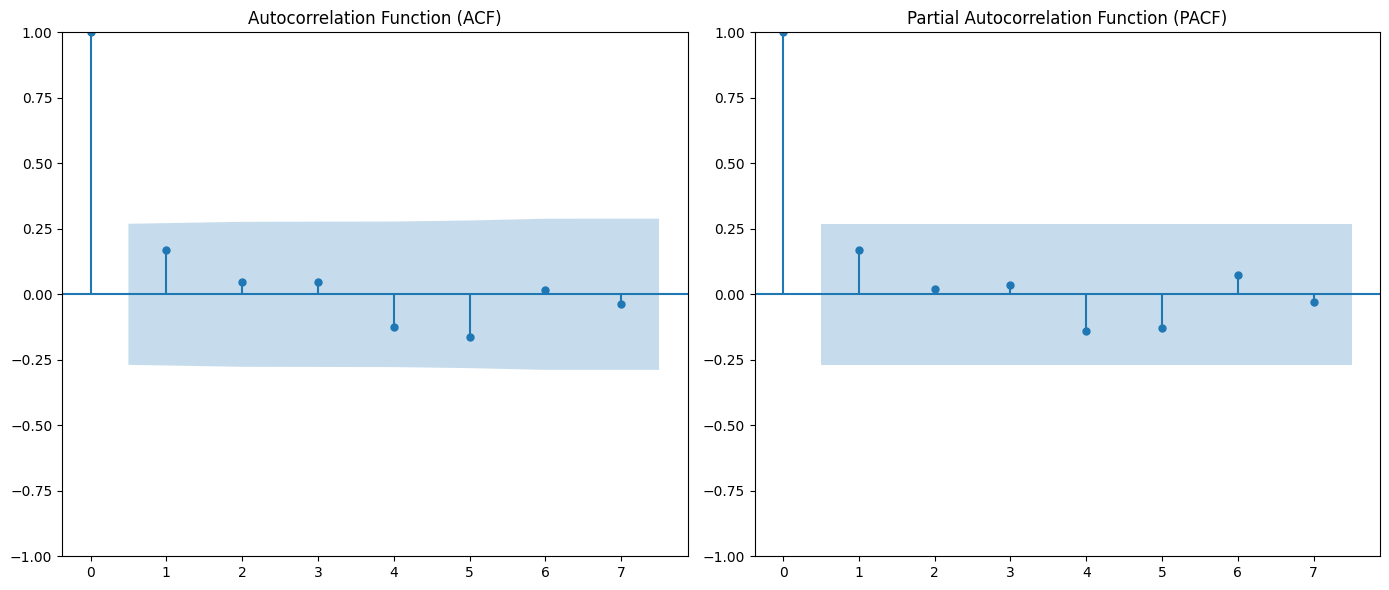

In [214]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

weekly_sales = sale.groupby(sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time))['quantity'].sum()


# Plot ACF and PACF
plt.figure(figsize=(14, 6))

# ACF plot for identifying 'q'
plt.subplot(1, 2, 1)
plot_acf(weekly_sales.values, lags=7, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

# PACF plot for identifying 'p'
plt.subplot(1, 2, 2)
plot_pacf(weekly_sales.values, lags=7, ax=plt.gca(), method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()


Predictions:
2015-10-19    877.368168
2015-10-26    912.329705
2015-11-02    890.506842
2015-11-09    923.945519
2015-11-16    900.110296
2015-11-23    931.880182
2015-11-30    906.671210
2015-12-07    937.300130
2015-12-14    911.153666
2015-12-21    941.002195
2015-12-28    914.216258
Freq: W-MON, Name: predicted_mean, dtype: float64
MAPE: 18.73%


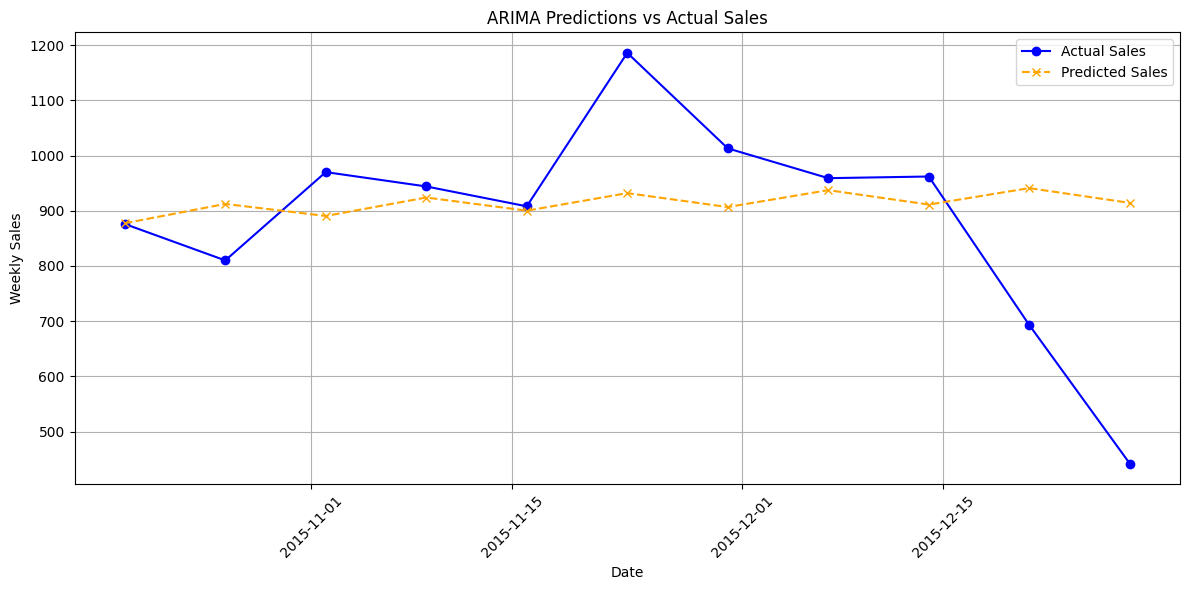

In [215]:
weekly_sales = sale.groupby(sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time))['quantity'].sum()
weekly_sales.index = pd.to_datetime(weekly_sales.index)
weekly_sales = weekly_sales.sort_index()

train_size = int(len(weekly_sales) * 0.8)
train_data, test_data = weekly_sales[:train_size], weekly_sales[train_size:]

model = ARIMA(train_data, order=(2, 0, 3))
arima_model = model.fit()

predictions = arima_model.forecast(steps=len(test_data))

print("Predictions:")
print(predictions)

mape = mean_absolute_percentage_error(test_data, predictions)
print(f'MAPE: {mape * 100:.2f}%')

plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label='Actual Sales', color='blue', marker='o')
plt.plot(predictions.index, predictions, label='Predicted Sales', color='orange', linestyle='--', marker='x')
plt.title('ARIMA Predictions vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [216]:
sale['order_date'] = pd.to_datetime(sale['order_date'])

weekly_sales = (
    sale.groupby([sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time), 'pizza_name_id'])['quantity']
    .sum()
    .reset_index()
)

weekly_sales_pivot = weekly_sales.pivot(index='order_date', columns='pizza_name_id', values='quantity').fillna(0)

next_week_predictions = {}

for pizza_name_id in weekly_sales_pivot.columns:
    pizza_sales = weekly_sales_pivot[pizza_name_id]

    train_size = int(len(pizza_sales) * 0.8)
    train_data, test_data = pizza_sales[:train_size], pizza_sales[train_size:]

    model = ARIMA(train_data, order=(2, 0, 3))
    arima_model = model.fit()

    forecast = arima_model.forecast(steps=1)[0]
    next_week_predictions[pizza_name_id] = round(forecast)

total_pizza_quantity = sum(next_week_predictions.values())

print("\nNext Week's Pizza Sales Predictions:")
for pizza_name_id, forecast in next_week_predictions.items():
    print(f'{pizza_name_id}: {forecast} units')

print(f'\nTotal Pizza Sales Prediction: {total_pizza_quantity} units')



Next Week's Pizza Sales Predictions:
bbq_ckn_l: 17 units
bbq_ckn_m: 19 units
bbq_ckn_s: 10 units
big_meat_s: 36 units
brie_carre_s: 8 units
calabrese_l: 5 units
calabrese_m: 11 units
calabrese_s: 2 units
cali_ckn_l: 17 units
cali_ckn_m: 22 units
cali_ckn_s: 11 units
ckn_alfredo_l: 4 units
ckn_alfredo_m: 10 units
ckn_alfredo_s: 2 units
ckn_pesto_l: 7 units
ckn_pesto_m: 7 units
ckn_pesto_s: 5 units
classic_dlx_l: 9 units
classic_dlx_m: 26 units
classic_dlx_s: 18 units
five_cheese_l: 31 units
four_cheese_l: 23 units
four_cheese_m: 12 units
green_garden_l: 1 units
green_garden_m: 5 units
green_garden_s: 11 units
hawaiian_l: 19 units
hawaiian_m: 9 units
hawaiian_s: 18 units
ital_cpcllo_l: 15 units
ital_cpcllo_m: 8 units
ital_cpcllo_s: 8 units
ital_supr_l: 14 units
ital_supr_m: 15 units
ital_supr_s: 3 units
ital_veggie_l: 5 units
ital_veggie_m: 9 units
ital_veggie_s: 6 units
mediterraneo_l: 8 units
mediterraneo_m: 5 units
mediterraneo_s: 6 units
mexicana_l: 20 units
mexicana_m: 8 units
mexi

#### SARIMAX Model

Predictions:
2015-10-19    852.048047
2015-10-26    954.248679
2015-11-02    895.423813
2015-11-09    710.806217
2015-11-16    938.733416
2015-11-23    803.047883
2015-11-30    860.435581
2015-12-07    826.112423
2015-12-14    908.820961
2015-12-21    857.609101
2015-12-28    672.846600
Freq: W-MON, Name: predicted_mean, dtype: float64
MAPE: 18.09%


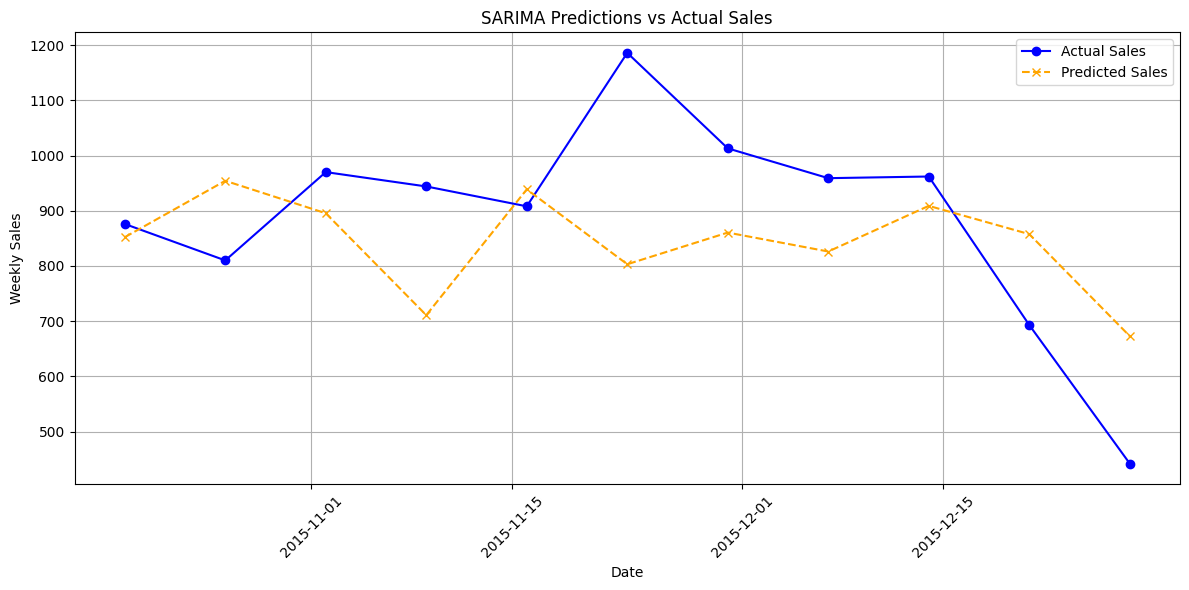

In [217]:
weekly_sales = sale.groupby(sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time))['quantity'].sum()
weekly_sales.index = pd.to_datetime(weekly_sales.index)
weekly_sales = weekly_sales.sort_index()

train_size = int(len(weekly_sales) * 0.8)
train_data, test_data = weekly_sales[:train_size], weekly_sales[train_size:]

model = SARIMAX(train_data, 
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False, 
                enforce_invertibility=False)
sarima_model = model.fit()

predictions = sarima_model.forecast(steps=len(test_data))

print("Predictions:")
print(predictions)

mape = mean_absolute_percentage_error(test_data, predictions)
print(f'MAPE: {mape * 100:.2f}%')

plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label='Actual Sales', color='blue', marker='o')
plt.plot(test_data.index, predictions, label='Predicted Sales', color='orange', linestyle='--', marker='x')
plt.title('SARIMA Predictions vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [218]:
sale['order_date'] = pd.to_datetime(sale['order_date'])

weekly_sales = (
    sale.groupby([sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time), 'pizza_name_id'])['quantity']
    .sum()
    .reset_index()
)

weekly_sales_pivot = weekly_sales.pivot(index='order_date', columns='pizza_name_id', values='quantity').fillna(0)

next_week_predictions = {}

for pizza_name_id in weekly_sales_pivot.columns:
    pizza_sales = weekly_sales_pivot[pizza_name_id]

    train_size = int(len(pizza_sales) * 0.8)
    train_data, test_data = pizza_sales[:train_size], pizza_sales[train_size:]

    model = SARIMAX(train_data,
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 7),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    sarima_model = model.fit()

    forecast = sarima_model.forecast(steps=1)[0] 
    next_week_predictions[pizza_name_id] = round(forecast) 

total_pizza_quantity = sum(next_week_predictions.values())

print("\nNext Week's Pizza Sales Predictions:")
for pizza_name_id, forecast in next_week_predictions.items():
    print(f'{pizza_name_id}: {forecast} units')

print(f'\nTotal Pizza Sales Prediction: {total_pizza_quantity} units')


Next Week's Pizza Sales Predictions:
bbq_ckn_l: 15 units
bbq_ckn_m: 20 units
bbq_ckn_s: 14 units
big_meat_s: 32 units
brie_carre_s: 16 units
calabrese_l: 1 units
calabrese_m: 10 units
calabrese_s: 0 units
cali_ckn_l: 17 units
cali_ckn_m: 9 units
cali_ckn_s: 10 units
ckn_alfredo_l: 4 units
ckn_alfredo_m: 13 units
ckn_alfredo_s: 1 units
ckn_pesto_l: 9 units
ckn_pesto_m: 3 units
ckn_pesto_s: 3 units
classic_dlx_l: 6 units
classic_dlx_m: 24 units
classic_dlx_s: 14 units
five_cheese_l: 28 units
four_cheese_l: 27 units
four_cheese_m: 11 units
green_garden_l: 2 units
green_garden_m: 8 units
green_garden_s: 11 units
hawaiian_l: 15 units
hawaiian_m: 4 units
hawaiian_s: 15 units
ital_cpcllo_l: 15 units
ital_cpcllo_m: 9 units
ital_cpcllo_s: 7 units
ital_supr_l: 14 units
ital_supr_m: 11 units
ital_supr_s: 1 units
ital_veggie_l: 6 units
ital_veggie_m: 8 units
ital_veggie_s: 7 units
mediterraneo_l: 7 units
mediterraneo_m: 6 units
mediterraneo_s: 5 units
mexicana_l: 17 units
mexicana_m: 7 units
mexi

#### Prophet Model

14:45:15 - cmdstanpy - INFO - Chain [1] start processing
14:45:15 - cmdstanpy - INFO - Chain [1] done processing


Predictions:
[943.3947771  943.17951408 942.96425106 942.74898804 942.53372502
 942.318462   942.10319898 941.88793596 941.67267294 941.45740993
 941.24214691]
MAPE: 19.19%


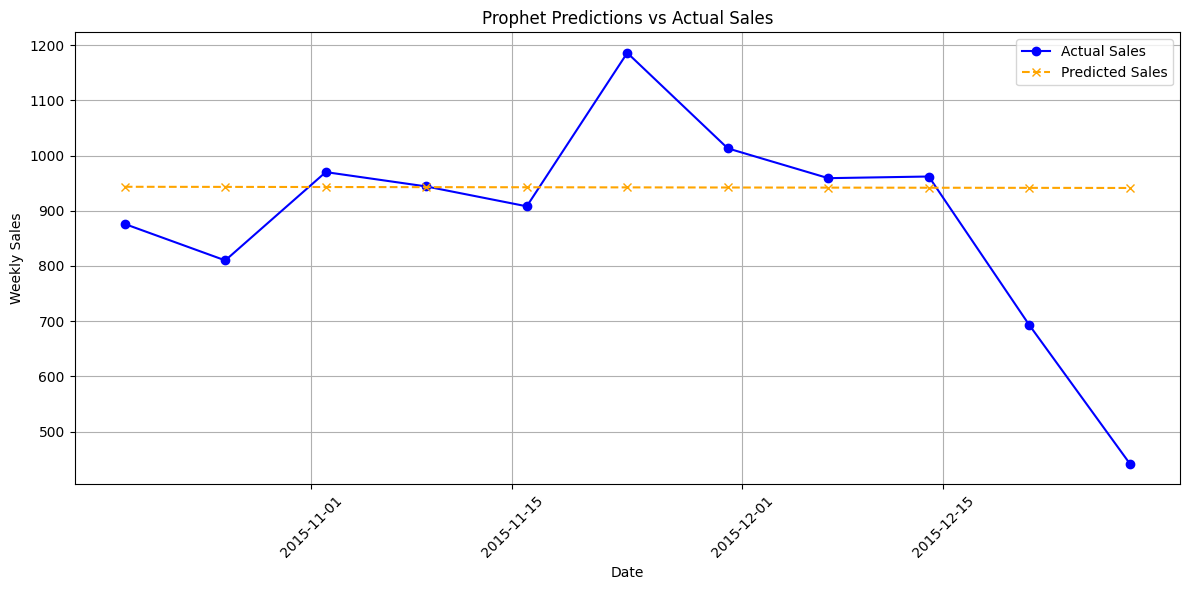

In [219]:
weekly_sales = sale.groupby(sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time))['quantity'].sum()

weekly_sales.index = pd.to_datetime(weekly_sales.index)
weekly_sales = weekly_sales.sort_index()

prophet_data = weekly_sales.reset_index()
prophet_data.columns = ['ds', 'y']

train_size = int(len(prophet_data) * 0.8)
train_data, test_data = prophet_data[:train_size], prophet_data[train_size:]

model = Prophet()
model.fit(train_data)

future = model.make_future_dataframe(periods=len(test_data), freq='W')

forecast = model.predict(future)

predictions = forecast['yhat'][-len(test_data):].values

print("Predictions:")
print(predictions)

mape = mean_absolute_percentage_error(test_data['y'].values, predictions)
print(f'MAPE: {mape * 100:.2f}%')

plt.figure(figsize=(12, 6))
plt.plot(test_data['ds'], test_data['y'], label='Actual Sales', color='blue', marker='o')
plt.plot(test_data['ds'], predictions, label='Predicted Sales', color='orange', linestyle='--', marker='x')
plt.title('Prophet Predictions vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [220]:
sale['order_date'] = pd.to_datetime(sale['order_date'])

weekly_sales = (
    sale.groupby([sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time), 'pizza_name_id'])['quantity']
    .sum()
    .reset_index()
)

next_week_predictions = {}

for pizza_name_id in weekly_sales['pizza_name_id'].unique():
    pizza_sales = weekly_sales[weekly_sales['pizza_name_id'] == pizza_name_id]
    
    prophet_data = pizza_sales.rename(columns={'order_date': 'ds', 'quantity': 'y'})
    prophet_data = prophet_data[['ds', 'y']]
    
    train_size = int(len(prophet_data) * 0.8)
    train_data, test_data = prophet_data[:train_size], prophet_data[train_size:]
    
    model = Prophet()
    model.fit(train_data)
    
    future = model.make_future_dataframe(periods=len(test_data) + 1, freq='W')

    forecast = model.predict(future)
    
    next_week_forecast = round(forecast.iloc[-1]['yhat'])
    next_week_predictions[pizza_name_id] = next_week_forecast

total_pizza_quantity = sum(next_week_predictions.values())

print("\nNext Week's Pizza Sales Predictions:")
for pizza_name_id, forecast in next_week_predictions.items():
    print(f'{pizza_name_id}: {forecast} units')

print(f'\nTotal Pizza Sales Prediction: {total_pizza_quantity} units')


14:45:18 - cmdstanpy - INFO - Chain [1] start processing
14:45:18 - cmdstanpy - INFO - Chain [1] done processing
14:45:18 - cmdstanpy - INFO - Chain [1] start processing
14:45:18 - cmdstanpy - INFO - Chain [1] done processing
14:45:19 - cmdstanpy - INFO - Chain [1] start processing
14:45:19 - cmdstanpy - INFO - Chain [1] done processing
14:45:19 - cmdstanpy - INFO - Chain [1] start processing
14:45:19 - cmdstanpy - INFO - Chain [1] done processing
14:45:19 - cmdstanpy - INFO - Chain [1] start processing
14:45:19 - cmdstanpy - INFO - Chain [1] done processing
14:45:19 - cmdstanpy - INFO - Chain [1] start processing
14:45:20 - cmdstanpy - INFO - Chain [1] done processing
14:45:20 - cmdstanpy - INFO - Chain [1] start processing
14:45:20 - cmdstanpy - INFO - Chain [1] done processing
14:45:20 - cmdstanpy - INFO - Chain [1] start processing
14:45:20 - cmdstanpy - INFO - Chain [1] done processing
14:45:20 - cmdstanpy - INFO - Chain [1] start processing
14:45:20 - cmdstanpy - INFO - Chain [1]


Next Week's Pizza Sales Predictions:
bbq_ckn_l: 16 units
bbq_ckn_m: 19 units
bbq_ckn_s: 9 units
big_meat_s: 37 units
brie_carre_s: 10 units
calabrese_m: 11 units
calabrese_s: 2 units
cali_ckn_l: 17 units
cali_ckn_m: 15 units
cali_ckn_s: 10 units
ckn_alfredo_l: 3 units
ckn_alfredo_m: 13 units
ckn_alfredo_s: 3 units
ckn_pesto_l: 8 units
ckn_pesto_m: 6 units
ckn_pesto_s: 5 units
classic_dlx_l: 9 units
classic_dlx_m: 26 units
classic_dlx_s: 16 units
five_cheese_l: 27 units
four_cheese_l: 24 units
four_cheese_m: 11 units
green_garden_l: 2 units
green_garden_m: 6 units
green_garden_s: 13 units
hawaiian_l: 19 units
hawaiian_m: 10 units
hawaiian_s: 17 units
ital_cpcllo_l: 15 units
ital_cpcllo_m: 6 units
ital_cpcllo_s: 5 units
ital_supr_l: 14 units
ital_supr_m: 16 units
ital_supr_s: 4 units
ital_veggie_l: 3 units
ital_veggie_m: 8 units
ital_veggie_s: 4 units
mediterraneo_l: 7 units
mediterraneo_m: 6 units
mediterraneo_s: 6 units
mexicana_l: 15 units
mexicana_m: 7 units
mexicana_s: 4 units
napo

#### LSTM Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
MAPE: 12.18%
Predictions:
order_date
2015-11-09     912.211853
2015-11-16     926.034241
2015-11-23     960.520447
2015-11-30     990.274780
2015-12-07    1020.322754
2015-12-14    1057.600952
2015-12-21     986.435181
dtype: float32


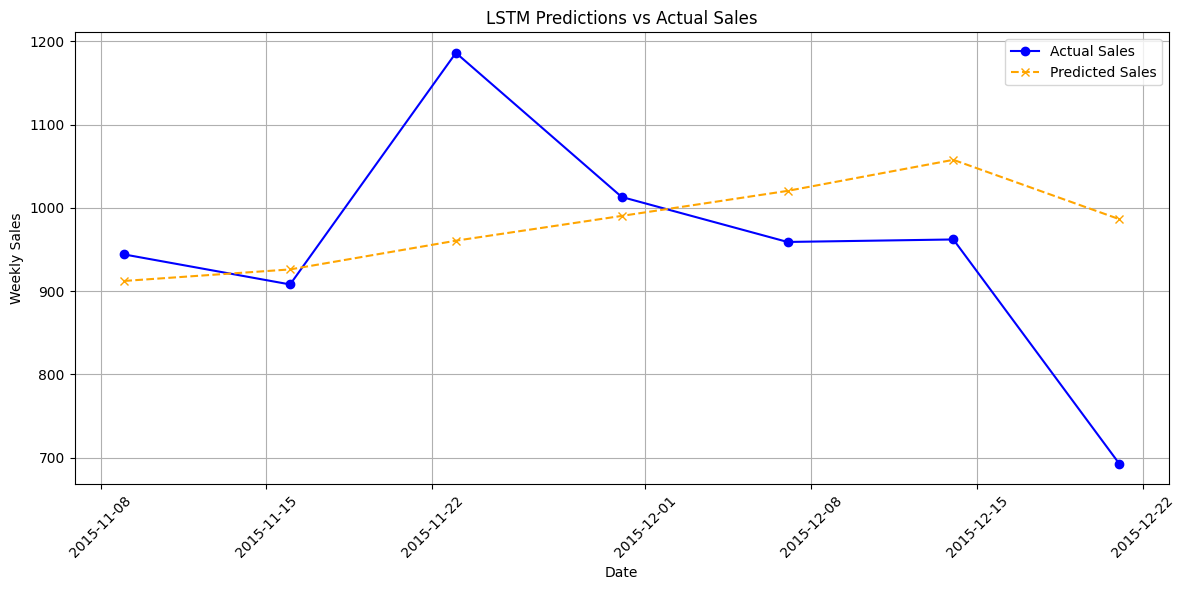

In [221]:
weekly_sales = sale.groupby(sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time))['quantity'].sum().reset_index()

weekly_sales.index = pd.to_datetime(weekly_sales.index)
weekly_sales = weekly_sales.sort_index()

train_size = int(0.8 * len(weekly_sales))
train, test = weekly_sales[:train_size], weekly_sales[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[['quantity']])
test_scaled = scaler.transform(test[['quantity']])

def create_dataset(data, time_steps=1):
    X, y = [], []
    for i in range(len(data)-time_steps-1):
        X.append(data[i:(i+time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 3 

X_train, y_train = create_dataset(train_scaled, time_steps)
X_test, y_test = create_dataset(test_scaled, time_steps)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

lstm_model = Sequential()
lstm_model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dense(units=1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

predictions = lstm_model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

mape = mean_absolute_percentage_error(y_test_rescaled, predictions)
print(f'MAPE: {mape * 100:.2f}%')

lstm_predictions = pd.Series(predictions.flatten(), index=test['order_date'][time_steps:len(predictions) + time_steps])

print("Predictions:")
print(lstm_predictions)

plt.figure(figsize=(12, 6))
plt.plot(test['order_date'][time_steps:len(predictions) + time_steps], y_test_rescaled, label='Actual Sales', color='blue', marker='o')
plt.plot(lstm_predictions.index, lstm_predictions, label='Predicted Sales', color='orange', linestyle='--', marker='x')
plt.title('LSTM Predictions vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [222]:
sale['order_date'] = pd.to_datetime(sale['order_date'])

weekly_sales = (
    sale.groupby([sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time), 'pizza_name_id'])['quantity']
    .sum()
    .reset_index()
)

def create_dataset(data, time_steps=1):
    X, y = [], []
    for i in range(len(data) - time_steps - 1):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 3  

next_week_predictions = {}

for pizza_name_id in weekly_sales['pizza_name_id'].unique():
    pizza_sales = weekly_sales[weekly_sales['pizza_name_id'] == pizza_name_id]
    pizza_sales = pizza_sales.sort_values(by='order_date').reset_index(drop=True)

    train_size = int(0.8 * len(pizza_sales))
    train, test = pizza_sales[:train_size], pizza_sales[train_size:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train[['quantity']])
    test_scaled = scaler.transform(test[['quantity']])

    X_train, y_train = create_dataset(train_scaled, time_steps)
    X_test, y_test = create_dataset(test_scaled, time_steps)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    lstm_model = Sequential()
    lstm_model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))
    lstm_model.add(Dense(units=1))

    lstm_model.compile(optimizer='adam', loss='mse')

    lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    last_window = train_scaled[-time_steps:].reshape(1, time_steps, 1)
    next_week_forecast = lstm_model.predict(last_window)
    next_week_forecast = scaler.inverse_transform(next_week_forecast).flatten()[0]
  
    next_week_predictions[pizza_name_id] = round(next_week_forecast)

total_pizza_quantity = sum(next_week_predictions.values())

print("\nNext Week's Pizza Sales Predictions:")
for pizza_name_id, forecast in next_week_predictions.items():
    print(f'{pizza_name_id}: {forecast} units')

print(f'\nTotal Pizza Sales Prediction: {total_pizza_quantity} units')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

#### Model Comparision

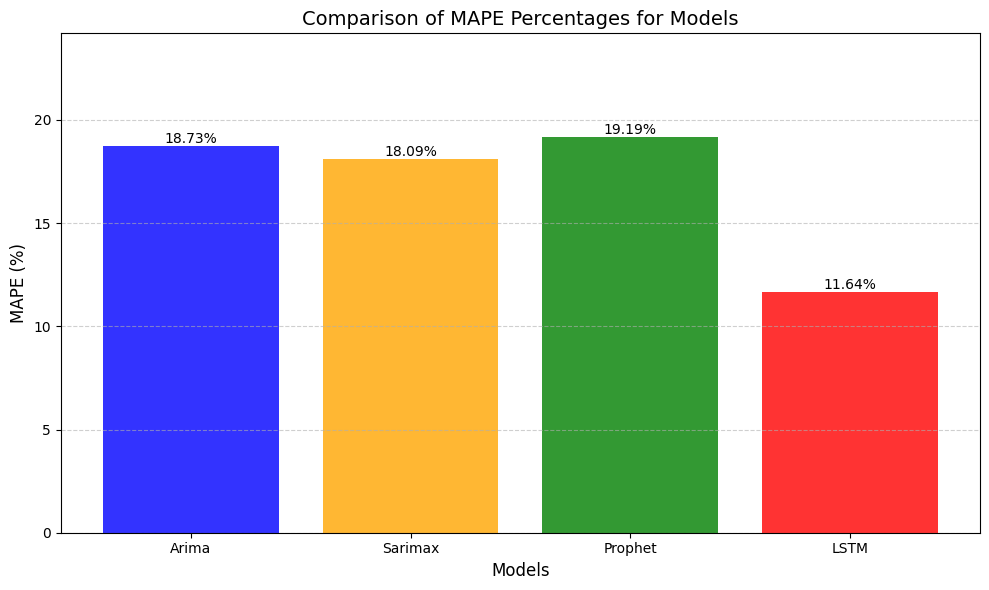

In [223]:
Model_Mape_percents = {'Arima': 18.73, 'Sarimax': 18.09, 'Prophet': 19.19, 'LSTM': 11.64}

models = list(Model_Mape_percents.keys())
mape_values = list(Model_Mape_percents.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(models, mape_values, color=['blue', 'orange', 'green', 'red'], alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title('Comparison of MAPE Percentages for Models', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('MAPE (%)', fontsize=12)
plt.ylim(0, max(mape_values) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [224]:
joblib.dump(lstm_model, 'best_LSTM_mdel.joblib')

['best_LSTM_mdel.joblib']

### Sales Forecasting Using best model - *LSTM*

In [225]:
# Ensure 'order_date' is a datetime
sale['order_date'] = pd.to_datetime(sale['order_date'])

# Aggregate weekly sales by pizza_name_id
weekly_sales = (
    sale.groupby([sale['order_date'].dt.to_period('W').apply(lambda r: r.start_time), 'pizza_name_id'])['quantity']
    .sum()
    .reset_index()
)

def create_dataset(data, time_steps=1):
    X, y = [], []
    for i in range(len(data) - time_steps - 1):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 3  

next_week_predictions = {}

for pizza_name_id in weekly_sales['pizza_name_id'].unique():
    # Filter sales for the current pizza_name_id
    pizza_sales = weekly_sales[weekly_sales['pizza_name_id'] == pizza_name_id]
    pizza_sales = pizza_sales.sort_values(by='order_date').reset_index(drop=True)

    train_size = int(0.8 * len(pizza_sales))
    train, test = pizza_sales[:train_size], pizza_sales[train_size:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train[['quantity']])
    test_scaled = scaler.transform(test[['quantity']])

    X_train, y_train = create_dataset(train_scaled, time_steps)
    X_test, y_test = create_dataset(test_scaled, time_steps)
    
    # Reshape X for LSTM input
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(Dense(units=1))
    
    model.compile(optimizer='adam', loss='mse')
 
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    
    # Make predictions for the next week
    last_window = train_scaled[-time_steps:].reshape(1, time_steps, 1)
    next_week_forecast = model.predict(last_window)
    next_week_forecast = scaler.inverse_transform(next_week_forecast).flatten()[0]
    
    # Round and store the prediction
    next_week_predictions[pizza_name_id] = round(next_week_forecast)

ingredients_df = ingridients.copy()
ingredients_df['required_quantity_in_grams'] = 0

ingredient_requirements = pd.DataFrame(columns=['pizza_ingredients', 'required_quantity_in_grams'])

# Calculate ingredient requirements based on predictions
for pizza_name_id, forecast in next_week_predictions.items():
    # Filter ingredient data for the current pizza_name_id
    ingredient_data = ingredients_df[ingredients_df['pizza_name_id'] == pizza_name_id].copy()
    
    # Calculate the required quantities
    ingredient_data['required_quantity_in_grams'] = ingredient_data['Items_Qty_In_Grams'] * forecast
    
    ingredient_requirements = pd.concat([ingredient_requirements, ingredient_data[['pizza_ingredients', 'required_quantity_in_grams']]])

ingredient_requirements = ingredient_requirements.groupby('pizza_ingredients', as_index=False)['required_quantity_in_grams'].sum()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [226]:
print("\nIngredient Requirements for Next Week's Pizza Sales:")
ingredient_requirements


Ingredient Requirements for Next Week's Pizza Sales:


,pizza_ingredients,required_quantity_in_grams
0,Alfredo Sauce,295.0
1,Anchovies,830.0
2,Artichokes,2265.0
3,Arugula,305.0
4,Asiago Cheese,1340.0
...,...,...
59,Sun-dried Tomatoes,320.0
60,Thai Sweet Chilli Sauce,1090.0
61,Thyme,45.0
62,Tomatoes,11150.0


In [227]:
total_pizza_quantity = sum(next_week_predictions.values())
print(f'\nTotal Pizza Sales Prediction: {total_pizza_quantity} units')


Total Pizza Sales Prediction: 928 units


In [228]:
purchase_order = ingredient_requirements.copy()
purchase_order['unit'] = 'grams'
purchase_order['remarks'] = 'For next week\'s pizza sales'

po_metadata = {
    'PO Number': f"PO-{pd.Timestamp.now().strftime('%Y%m%d%H%M%S')}",
    'Date': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'Supplier': 'Dominos Pizza Ingredients SUpplier.',
    'Delivery Deadline': (pd.Timestamp.now() + pd.Timedelta(days=7)).strftime('%Y-%m-%d'),
}

print("\nPurchase Order Metadata:")
for key, value in po_metadata.items():
    print(f'{key}: {value}')

print("\nPurchase Order Details:")
purchase_order



Purchase Order Metadata:
PO Number: PO-20250112150316
Date: 2025-01-12
Supplier: Dominos Pizza Ingredients SUpplier.
Delivery Deadline: 2025-01-19

Purchase Order Details:


,pizza_ingredients,required_quantity_in_grams,unit,remarks
0,Alfredo Sauce,295.0,grams,For next week's pizza sales
1,Anchovies,830.0,grams,For next week's pizza sales
2,Artichokes,2265.0,grams,For next week's pizza sales
3,Arugula,305.0,grams,For next week's pizza sales
4,Asiago Cheese,1340.0,grams,For next week's pizza sales
...,...,...,...,...
59,Sun-dried Tomatoes,320.0,grams,For next week's pizza sales
60,Thai Sweet Chilli Sauce,1090.0,grams,For next week's pizza sales
61,Thyme,45.0,grams,For next week's pizza sales
62,Tomatoes,11150.0,grams,For next week's pizza sales


In [229]:
po_filename = f"Purchase_Order_{po_metadata['PO Number']}.csv"
purchase_order.to_csv(po_filename, index=False)
print(f"\nPurchase Order saved as: {po_filename}")


Purchase Order saved as: Purchase_Order_PO-20250112150316.csv
